In [31]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from math import sqrt

import os

# Information About Dataset

In [32]:
df = pd.read_csv('IceCreamData.csv')
df.sample(10)

,Temperature,Revenue
43,14.109661,358.002849
137,28.547987,656.636523
376,34.860701,798.059718
436,17.188948,390.879119
231,20.153345,449.112869
206,23.959312,537.113833
387,14.731824,322.983977
40,23.003489,539.688006
122,28.262831,655.433979
361,29.704183,659.873287


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [34]:
df.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


# Data Visualization

<Figure size 1280x960 with 0 Axes>

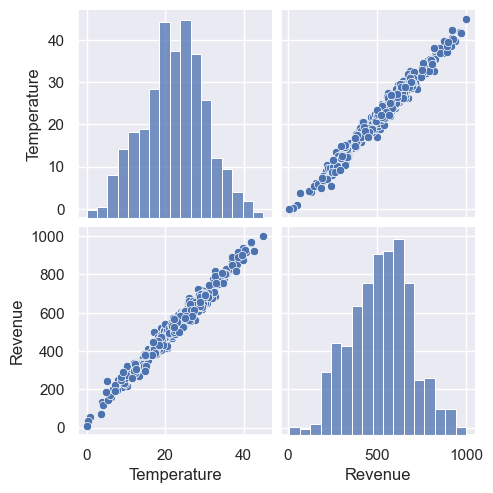

In [35]:
plt.figure(dpi = (200))
sns.pairplot(df)

<Figure size 640x480 with 0 Axes>

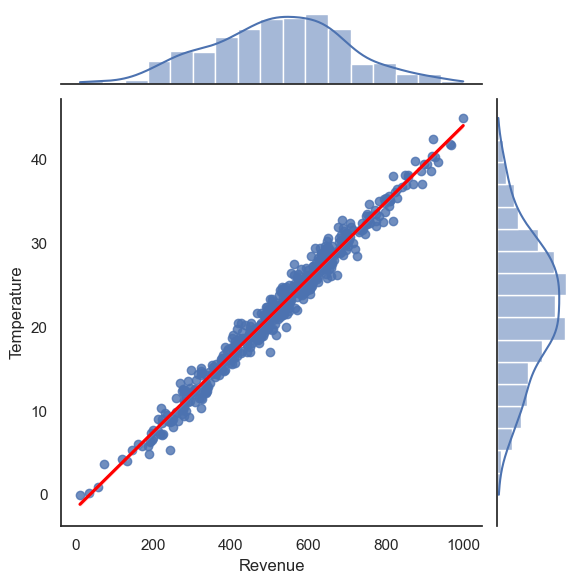

In [36]:
sns.set_theme(style="white")
plt.figure(dpi = (100))
sns.jointplot(x = df['Revenue'], y = df['Temperature'], kind='reg', line_kws={"color": "red"})

<Axes: xlabel='Revenue', ylabel='Temperature'>

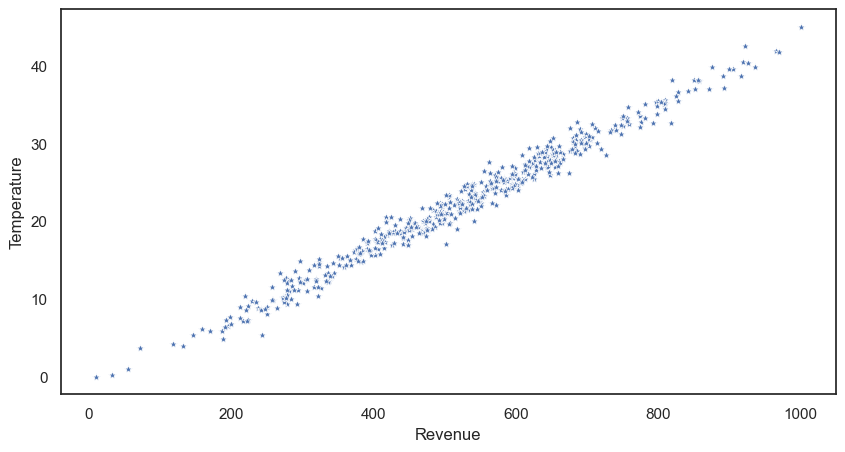

In [37]:
plt.figure(figsize = (10,5), dpi = (100))
sns.scatterplot(x = df['Revenue'], y = df['Temperature'], marker="*")

# Train-Test Split

In [38]:
from sklearn.model_selection import train_test_split

X = df[['Temperature']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 101)

print(f'Total # of sample in whole dataset: {len(X)}')
print("*****"*10)
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Shape of X_train: {X_train.shape}')
print("*****"*10)
print(f'Total # of sample in test dataset: {len(X_test)}')
print(f'Shape of X_test: {X_test.shape}')

Total # of sample in whole dataset: 500
**************************************************
Total # of sample in train dataset: 335
Shape of X_train: (335, 1)
**************************************************
Total # of sample in test dataset: 165
Shape of X_test: (165, 1)


# Linear Regression

In [39]:
model = LinearRegression(fit_intercept = True)

In [40]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
pred = model.predict(X_test)

In [42]:
train_score = model.score(X_train, y_train)
print(f'Train score of trained model: {train_score*100}')

test_score = model.score(X_test, y_test)
print(f'Test score of trained model: {test_score*100}')

Train score of trained model: 97.86733638283377
Test score of trained model: 98.18365687594093


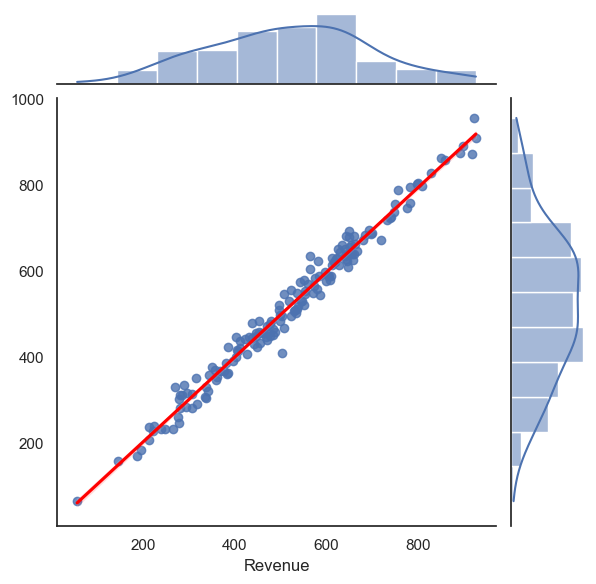

In [43]:
sns.set_theme(style="white")
sns.jointplot(x=y_test, y=pred, kind='reg', line_kws={"color": "red"})

# Evaluation of Model

## Mean Squared Error

Mean Square Error (MSE) is the most commonly used regression loss function. MSE is the average loss of frames per sample across the entire dataset. To calculate the MSE, sum all frame losses for individual samples and then divide by the number of samples.

In [44]:
print("Mean Squared Error:",mean_squared_error(y_test, pred))

Mean Squared Error: 549.2134978280799


## Root Mean Squared Error

It is a quadratic metric that measures the magnitude of the error, often used to find the distance between the predictor's predicted values and the actual values of a machine learning model. The standard deviation of the RMSE estimation errors (residues). That is, the residuals are a measure of how far the regression line is from the data points; RMSE is a measure of how far these residues spread. In other words, it tells you how dense that data is around the line that best fits the data. The RMSE value can range from 0 to infinity. Negative oriented scores, i.e. predictors with lower values, perform better. A zero RMSE value means the model made no mistakes. RMSE has the advantage of punishing large errors more so it may be better suited to some situations. RMSE prevents the unwanted use of absolute values in many mathematical calculations.

In [45]:
print("Root Mean Squared Error:",np.sqrt(mean_squared_error(y_test, pred)))

Root Mean Squared Error: 23.435304517502644


## Mean Absolute Error

Absolute error is the difference between estimated values and actual values. To be exact, it is the mean of the absolute value of each difference between the actual value and the predicted value for that sample across the entire sample of the data set.

In [46]:
print("Mean Absolute Error:",mean_absolute_error(y_test, pred))

Mean Absolute Error: 18.723628423305332


## Mean Absolute Percentage Error

In regression and time series models, mean absolute percent error is frequently used to measure the accuracy of predictions. If there are zero among the real values, the MAPE cannot be calculated as there will be division by zero. Percentage error cannot exceed 100% for very low predictive values, but there is no upper limit for the percentage error for very high predictive values. When MAPE is used to compare the accuracy of estimators, it is biased as it systematically selects a method that is too low for estimates. This small but serious problem can be overcome with an accuracy criterion that finds the ratio of predicted values to their true values. This approach leads to estimates that can be interpreted in terms of the geometric mean.


In [47]:
print("Mean Absolute Percentage Error:",np.mean(np.abs( (y_test-pred) / y_test))*100)

Mean Absolute Percentage Error: 4.210864067222878


## R square

R² is a statistical measure of how close the data are to the fitted regression line. It is also known as the coefficient of determination or the multiple coefficient of determination for multiple regression. To put it in simpler language, R-square is a measure of fit for linear regression models.



R-squared does not indicate whether a regression model fits your data adequately. A good model can have a low R-squared value. On the other hand, a biased model can have a high R-squared value!


In [48]:
print("R^2:",r2_score(y_test, pred))

R^2: 0.9818365687594093


## Adjusted R Squared

Each additional argument added to a model always increases the R² value.

As the independent variable is added, the model becomes more complex, when the model becomes complex, "overfitting" occurs. Hence R-squared increases.

Adjusted R-square comes into play to solve such problems. The adjusted R-square compensates for each independent variable and only increases when each given variable improves the model above what is possible.

In [49]:
n=X_test.shape[0]
p=X_test.shape[1] - 1
R2 = m.r2_score(y_test, pred)

adj_rsquared = 1 - (1 - R2) * ((n - 1)/(n-p-1))
print('Adjusted R Squared: {}'.format(adj_rsquared))

Adjusted R Squared: 0.9818365687594093


## Let's put it all together

In [50]:
k = X_test.shape[1]
n = len(X_test)

MSE = mean_squared_error(y_test, pred)
RMSE = np.sqrt(metrics.mean_squared_error(y_test, pred))
MAE = mean_absolute_error(y_test, pred)
MAPE = np.mean(np.abs( (y_test-pred) / y_test))*100
r2 = r2_score(y_test, pred)
adj_r2 = 1-(1-r2) * (n-1)/(n-k-1)

In [51]:
results = [MSE, RMSE, MAE, MAPE, r2, adj_r2]
metrics = ['MSE', 'RMSE', 'MAE', 'MAPE', 'r2', 'adj_r2']

table_results = pd.DataFrame({'Metric': metrics, 'Score': results})
table_results

,Metric,Score
0,MSE,549.213498
1,RMSE,23.435305
2,MAE,18.723628
3,MAPE,4.210864
4,r2,0.981837
5,adj_r2,0.981725
